# Adam: small denominators and intermittently zero gradients

A lightweight companion to the other Adam demos. We use isotropic Gaussian data,
one output, zero target, and **$\beta_2=0$ throughout**. Stability is inside the
square root, $\sqrt{v+\epsilon}$. The experiments evaluate the stationary HAdam
coefficients at the population optimum and compare their small-learning-rate
risk predictions. They do not simulate finite-dimensional optimizer trajectories.

The infinite momentum history is summed analytically. All remaining integrals
are one-dimensional deterministic quadratures; no JAX, large sample arrays, or
history tensors are needed. Dependencies: NumPy, SciPy, Matplotlib.

## The gradient functions
The notation below is $f(\text{noise},q)$, where $q=\theta^\top x$.

**Experiment 1 (ordinary noisy regression):**
$$f(\zeta,q)=q-\zeta,\qquad \zeta\sim N(0,1),\qquad F(\zeta,q)=\tfrac12(q-\zeta)^2.$$

**Experiment 2 (infrequently zero gradients):**
$$f((\omega,\zeta),q)=\omega(q-\zeta),\qquad
F((\omega,\zeta),q)=\tfrac\omega2(q-\zeta)^2,\qquad
\omega\sim\mathrm{Bernoulli}(p),\quad p=0.9.$$
The gate is independent of the label noise, so exactly 10% of gradients vanish.
We show both $\zeta\sim N(0,1)$ and the outlier mixture
$0.99N(0,1)+0.01N(0,100^2)$. All noises and data are independent across samples.
The population excess risk is $p\|\theta\|^2/2$ (with $p=1$ in Experiment 1).

When an inactive sample arrives, SGD and signSGD make no update; Adam can retain
nonzero momentum and divide it by $\sqrt\epsilon$. At $\epsilon=0$, this case is
undefined for Adam with nonzero momentum. No zero-stability numerical division
is performed in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad_vec
from scipy.special import k0

# These explicit gradients describe the experiments (integration below is analytic).
def f_gaussian(noise, q):
    zeta = noise
    return q - zeta

def f_gated(noise, q):
    omega, zeta = noise
    return omega * (q - zeta)

models = {
    'Gaussian': dict(p=1.0, weights=np.array([1.0]), scales=np.array([1.0])),
    'Gated Gaussian': dict(p=0.9, weights=np.array([1.0]), scales=np.array([1.0])),
    'Gated outliers': dict(p=0.9, weights=np.array([0.99, 0.01]), scales=np.array([1.0, 100.0])),
}
beta2 = 0.0
betas = [0.0, 0.1, 0.5, 0.9, 0.99]
eps_grid = np.geomspace(1.0, 1e-10, 35)
fixed_eps = [1e-2, 1e-5, 1e-8]
quad_tol = 2e-9
assert beta2 == 0.0
assert np.all(eps_grid > 0)
for model in models.values():
    assert 0 < model['p'] <= 1
    assert np.isclose(model['weights'].sum(), 1)
    assert np.all(model['weights'] >= 0) and np.all(model['scales'] > 0)

## Exact stationary reduction and matched-rate objective
At the optimum, let $g=-\omega\zeta\xi$, with independent $\xi\sim N(0,1)$, and define
$$\mu=\mathbb E(g^2+\epsilon)^{-1/2},\quad
\nu=\mathbb E(g^2+\epsilon)^{-1},\quad
A=\mathbb E\frac{g^2}{\sqrt{g^2+\epsilon}},\quad
D_0=\mathbb E\frac{g^2}{g^2+\epsilon}.$$
Let $V=\mathbb E\zeta^2$. For the Gaussian mixture with weights $w_j$ and standard
deviations $\sigma_j$, put
$$C=p\sum_j w_j A_j/\sigma_j^2,$$
where $A_j$ is the active-sample expectation defining $A$ for component $j$.
Gaussian integration by parts gives the local restoring coefficient
$$c=(1-\beta)C+\beta p\mu.$$
The shared-history covariance, including all temporal correlations, is
$$s=(1-\beta)^2D_0+2\beta(1-\beta)\mu A
+\beta^2pV\left[\mu^2+\frac{1-\beta}{1+\beta}(\nu-\mu^2)\right].$$
These formulas hold for every fixed $0\le\beta=\beta_1<1$ and $\epsilon>0$.

Give SGD learning rate $h$ and Adam learning rate $hp/c$. Their leading local
energy contraction rates agree. In the limit $h\downarrow0$ at fixed epsilon,
the ratio of stationary excess risks is
$$J=\frac{p\,s}{V c^2}.$$
Thus $J=1$ is SGD efficiency. This is a local stationary comparison, not a
finite-learning-rate or finite-time convergence guarantee. For large $J$, the
learning rate must be correspondingly small for the local approximation to apply.

In [2]:
# The product g = sigma*Z*xi has density K_0(|g|/sigma)/(pi*sigma).
# Integrate in u=log(|g|/sigma). Scaled moments keep the quadrature conditioned.
# The finite integration range has negligible tails for the displayed parameters.
_moment_cache = {}
def active_moments(eps, sigma, tol=quad_tol, lower=-50.0, upper=4.0):
    key = (float(eps), float(sigma), float(tol), float(lower), float(upper))
    if key in _moment_cache:
        return _moment_cache[key]
    root_eps = np.sqrt(eps)
    def integrand(u):
        z = np.exp(u)
        g2 = (sigma*z)**2
        den = g2 + eps
        density_measure = (2/np.pi)*k0(z)*z
        return density_measure*np.array([
            root_eps/np.sqrt(den), eps/den,
            g2/(sigma*np.sqrt(den)), g2/den])
    scaled, error = quad_vec(integrand, lower, upper,
                             epsabs=tol, epsrel=tol, limit=150)
    result = scaled*np.array([1/root_eps, 1/eps, sigma, 1])
    _moment_cache[key] = result
    return result

def moments(eps, model):
    p, weights, scales = model['p'], model['weights'], model['scales']
    active = np.array([active_moments(eps, sig) for sig in scales])
    mu, nu, A, D0 = p*(weights @ active)
    mu += (1-p)/np.sqrt(eps)
    nu += (1-p)/eps
    C = p*np.sum(weights*active[:, 2]/scales**2)
    V = np.sum(weights*scales**2)
    return dict(mu=mu, nu=nu, A=A, D0=D0, C=C, V=V, p=p)

def coefficients(beta, m):
    beta = np.asarray(beta)
    assert np.all((beta >= 0) & (beta < 1))
    mu, nu, A, D0, C, V, p = (m[k] for k in ['mu','nu','A','D0','C','V','p'])
    var_H = max(nu-mu**2, 0.0)  # roundoff guard only
    c = (1-beta)*C + beta*p*mu
    s = ((1-beta)**2*D0 + 2*beta*(1-beta)*mu*A
         + beta**2*p*V*(mu**2+(1-beta)/(1+beta)*var_H))
    return c, s, p*s/(V*c*c)

def sign_ratio(model):
    V = np.sum(model['weights']*model['scales']**2)
    density_zero = np.sum(model['weights']/model['scales'])/np.sqrt(2*np.pi)
    return np.pi/(8*density_zero**2*V)

results = {}
for name, model in models.items():
    ms = [moments(eps, model) for eps in eps_grid]
    results[name] = dict(moments=ms, J=np.array([coefficients(np.array(betas), m)[2] for m in ms]))
print('Coefficient tables computed; no trajectory simulation was run.')

Coefficient tables computed; no trajectory simulation was run.


## Experiment 1: momentum destroys the same-sample cancellation
For $\beta=0$, $g/\sqrt{g^2+\epsilon}$ stays bounded, approaching signSGD.
For every fixed $\beta>0$, an older gradient is divided by a fresh denominator.
At zero stability, $\mathbb E|g|^{-1}$ and $\mathbb E|g|^{-2}$ are infinite.
Symmetry does not make the signed update integrable.

For the Gaussian product distribution,
$$\mu=\Theta(\log^2(1/\epsilon)),\quad
\nu=\Theta(\epsilon^{-1/2}\log(1/\epsilon)),\quad
J\sim\frac{1-\beta}{1+\beta}\frac{\nu}{\mu^2}\longrightarrow\infty.$$
The beta-zero curve instead approaches $\pi^2/4$. The asymptotic expression
need not approximate the full curve until epsilon is sufficiently small.

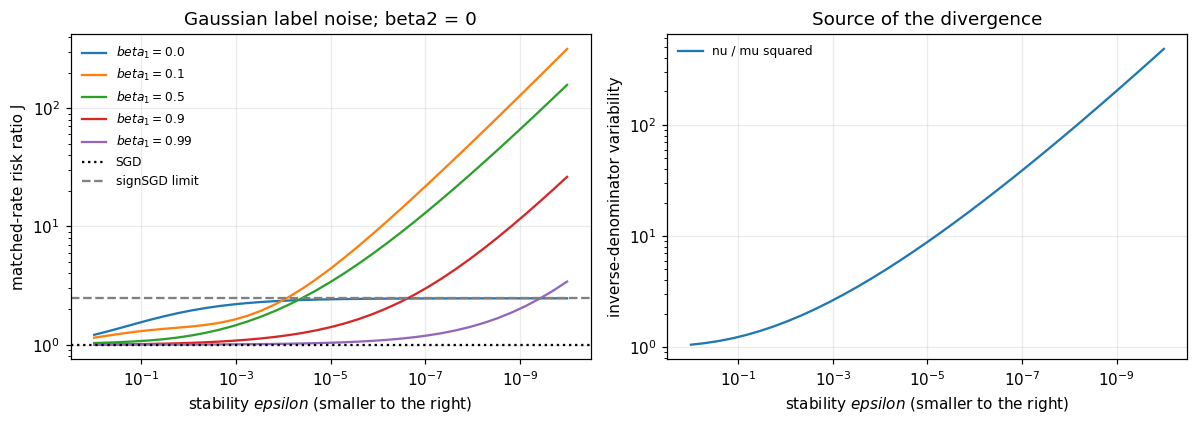

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j, beta in enumerate(betas):
    axes[0].loglog(eps_grid, results['Gaussian']['J'][:, j], label=fr'$beta_1={beta}$')
axes[0].axhline(1, color='k', ls=':', label='SGD')
axes[0].axhline(np.pi**2/4, color='0.5', ls='--', label='signSGD limit')
axes[0].set(xlabel=r'stability $epsilon$ (smaller to the right)', ylabel='matched-rate risk ratio J',
            title='Gaussian label noise; beta2 = 0')
ms = results['Gaussian']['moments']
mu = np.array([m['mu'] for m in ms])
nu = np.array([m['nu'] for m in ms])
axes[1].loglog(eps_grid, nu/mu**2, label='nu / mu squared')
axes[1].set(xlabel=r'stability $epsilon$ (smaller to the right)',
            ylabel='inverse-denominator variability', title='Source of the divergence')
for ax in axes:
    ax.invert_xaxis(); ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

## Experiment 2: inactive samples expose stored gradients
For $p<1$ and any fixed $\beta>0$,
$$J\longrightarrow 1+\frac{p}{1-p}\frac{1-\beta}{1+\beta}
\quad\text{as }\epsilon\downarrow0.$$
The limit depends on the gate probability, but not on the label-noise mixture.
At $\beta=0$, the signSGD limit *does* depend on the noise mixture:
$$J_{\rm sign}=\frac{\pi}{8g_\zeta(0)^2V}.$$
In particular, signSGD is robust to the rare large errors in the mixture, whereas
historical momentum retains their magnitudes. The limits $\beta\downarrow0$
and $\epsilon\downarrow0$ do not commute. Every finite-epsilon curve below is continuous.

Small-stability reference values (take small learning rate first):
Gated Gaussian: signSGD = 2.4674; SGD = 1; Adam beta1=0.5 -> 4
Gated outliers: signSGD = 0.024923; SGD = 1; Adam beta1=0.5 -> 4


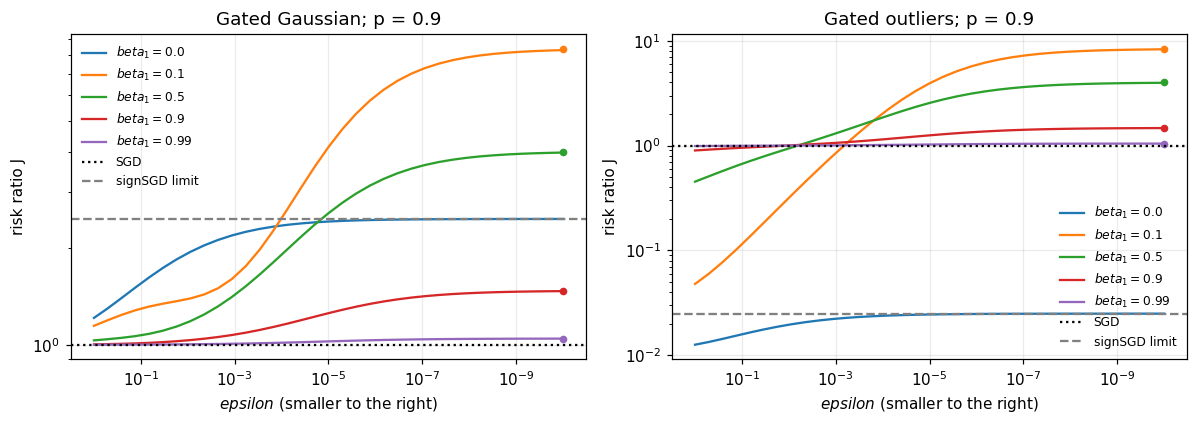

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ['Gated Gaussian', 'Gated outliers']):
    model = models[name]
    for j, beta in enumerate(betas):
        line, = ax.loglog(eps_grid, results[name]['J'][:, j], label=fr'$beta_1={beta}$')
        if beta > 0:
            limit = 1+model['p']/(1-model['p'])*(1-beta)/(1+beta)
            ax.plot(eps_grid[-1], limit, 'o', color=line.get_color(), ms=4)
    ax.axhline(1, color='k', ls=':', label='SGD')
    ax.axhline(sign_ratio(model), color='0.5', ls='--', label='signSGD limit')
    ax.set(title=name+'; p = 0.9', xlabel=r'$epsilon$ (smaller to the right)', ylabel='risk ratio J')
    ax.invert_xaxis(); ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

print('Small-stability reference values (take small learning rate first):')
for name in ['Gated Gaussian', 'Gated outliers']:
    model = models[name]
    print(f"{name}: signSGD = {sign_ratio(model):.5g}; SGD = 1; Adam beta1=0.5 -> 4")

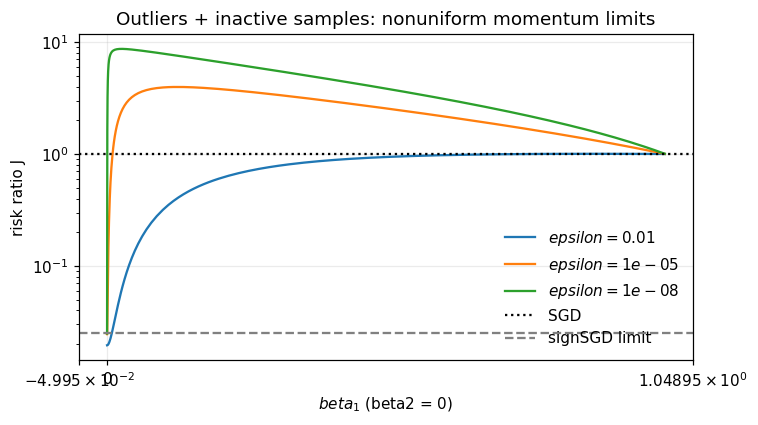

In [5]:
# A log-spaced grid resolves the narrow transition near beta1=0.
beta_grid = np.r_[0.0, np.geomspace(1e-6, 0.1, 100), np.linspace(0.11, 0.999, 100)]
fig, ax = plt.subplots(figsize=(7, 4))
model = models['Gated outliers']
for eps in fixed_eps:
    J = coefficients(beta_grid, moments(eps, model))[2]
    ax.plot(beta_grid, J, label=fr'$epsilon={eps:g}$')
ax.axhline(1, color='k', ls=':', label='SGD')
ax.axhline(sign_ratio(model), color='0.5', ls='--', label='signSGD limit')
ax.set(xscale='symlog', yscale='log', xlabel=r'$beta_1$ (beta2 = 0)',
       ylabel='risk ratio J', title='Outliers + inactive samples: nonuniform momentum limits')
ax.grid(alpha=0.25); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## Lightweight checks
These check positivity, beta-zero cancellation, and one quadrature calculation
against tighter tolerance and a larger integration interval. They are not a
large simulation study. The displayed asymptotics are separate analytic results;
finite grid values are not assumed to equal their limits.

In [6]:
for name, result in results.items():
    assert np.all(np.isfinite(result['J'])) and np.all(result['J'] > 0)
    for m in result['moments']:
        assert m['nu'] >= m['mu']**2*(1-1e-7)
        c, s, J = coefficients(0.0, m)
        assert np.isclose(s, m['D0']) and s <= m['p']*(1+1e-7)
coarse = active_moments(1e-8, 1.0)
fine = active_moments(1e-8, 1.0, tol=quad_tol/10, lower=-60, upper=5)
relative_change = np.max(np.abs(coarse-fine)/np.maximum(np.abs(fine), 1e-15))
assert relative_change < 1e-4
print(f'Checks passed. Quadrature refinement: max relative change {relative_change:.2e}.')
print('No calls were made at epsilon=0 or beta1=1.')

Checks passed. Quadrature refinement: max relative change 3.17e-13.
No calls were made at epsilon=0 or beta1=1.


The beta-zero, zero-stability reference uses sign(0)=0 for inactive samples.
For positive momentum, exact zero stability is undefined on inactive samples
and nonintegrable even without gates. Keep epsilon positive in numerical runs.

All comparisons use stationary coefficients and matched local drift. They do
not include startup, finite-dimensional errors, or a full nonlinear energy ODE.
Changing beta2 requires a different history calculation; these formulas are
specific to beta2=0.